# Практическая работа №7
# "Deep Learning"



> @Гришина Ксения, 23.Б16-мм



## 📒 Полный текст задания
(из файла с дз, дублирую для удобства)

> Практическая работа № 7

>Ваша задача будет исследовать эффективность различных архитектур глубокого обучения при решении одной задачи (классификации или регрессии) и оценить влияние оптимизации гиперпараметров и архитектурных особенностей сетей на качество модели. Кроме того, провести анализ устойчивости моделей, склонности к переобучению и чувствительности к структуре данных.

> 1. Выполнить расширенный препроцессинг данных.
> 2. Обучить две разные архитектуры глубоких нейронных сетей, например:
> - CNN + Bidirectional LSTM;
> - CNN + Transformer Encoder;
> - MLP + 1D CNN;
> - LSTM + GRU.
> 3. Провести подбор архитектуры и гиперпараметров с помощью Optuna.
> 4. Использовать несколько метрик качества
> 5. Построить графики обучения, валидации, переобучения и сравнить модели.
> 6. Провести анализ устойчивости моделей (например, через добавление шума или уменьшение обучающей выборки).
> 7. Сформировать обоснованные выводы об эффективности каждой архитектуры.




> Работа должна представлять собой ноутбук в GoogleCollab или Kagle (ссылка), оставленный комментарием напротив Вашей фамилии и даты выдачи работ. 

> Замечание: если будет использован GPT (как копипаст), то работа не будет засчитана. Если Вы предоставляете работу с использованием GPT - кода и это вычисляется, но это не полностью копипаст, то будет снижено 50% баллов. GPT можно использовать как источник информации, но это не должно быть скопировано и неосмысленно отправлено на проверку.

> P.P.S: GPT можно использовать для построения графиков, но интерпретация графиков должна быть написана Вашими словами

> ДД данной работы: 9.12.2025 до 23:59


## _ Теоретическая справка

**Цель работы** -  исследовать эффективность различных архитектур глубокого обучения при решении одной задачи (классификации или регрессии) и оценить влияние оптимизации гиперпараметров и архитектурных особенностей сетей на качество модели. Кроме того, провести анализ устойчивости моделей, склонности к переобучению и чувствительности к структуре данных.

**Задачи работы:**

- Задача регрессии на признаке `Global_Sales_log`

1. Обучить две разные архитектуры глубоких нейронных сетей, например:
- CNN + Bidirectional LSTM;
- CNN + Transformer Encoder;
- MLP + 1D CNN;
- LSTM + GRU.



**Используемые архитектуры**:

*   1 NN CNN + Bidirectional LSTM;
*   2 NN CNN + Transformer Encoder;
*   3 NN MLP + 1D CNN;
*   4 NN LSTM + GRU.


## 1 Расширенный препроцессинг данных

### Повтор практической работы №1

#### 1 Теоретическая справка

Для поиска своего набора данных воспользовалась поиском в [kaggle](https://www.kaggle.com/datasets/ibriiee/video-games-sales-dataset-2022-updated-extra-feat). Выбрала такой датасет о продажах видеоигр
(https://www.kaggle.com/datasets/ibriiee/video-games-sales-dataset-2022-updated-extra-feat)

На kaggle дали такое описание данным:



> Этот набор данных предоставляет актуальную информацию о продажах и популярности различных видеоигр по всему миру. Данные включают название, платформу, год выпуска, жанр, издателя и данные о продажах в Северной Америке, Европе, Японии и других регионах. Он также содержит оценки и рейтинги критиков и пользователей, включая средний рейтинг критиков, количество просмотренных игр, средний рейтинг пользователей, количество просмотренных игр, разработчика и рейтинг. Этот всеобъемлющий и важный набор данных предоставляет ценную информацию о мировом рынке видеоигр и является незаменимым инструментом для геймеров, профессионалов отрасли и исследователей рынка.



Записей: 16719.

**Признаки**(16 шт):
| Название колонки | Описание |
|------------------|----------|
| Name             | Название видеоигры |
| Platform         | Платформа, на которой была выпущена игра (PlayStation, Xbox, Nintendo и др.) |
| Year of Release  | Год выпуска игры |
| Genre            | Жанр видеоигры (экшен, приключения, спорт и др.) |
| Publisher        | Компания, выпустившая игру |
| NA Sales         | Продажи игры в Северной Америке (в млн USD) |
| EU Sales         | Продажи игры в Европе (в млн USD) |
| JP Sales         | Продажи игры в Японии (в млн USD) |
| Other Sales      | Продажи игры в других регионах (в млн USD) |
| Global Sales     | Общие мировые продажи игры (в млн USD) |
| Critic Score     | Средняя оценка игры от профессиональных критиков (0-100)|
| Critic Count     | Количество критиков, оценивших игру |
| User Score       | Средняя оценка игры от пользователей (0-10)|
| User Count       | Количество пользователей, оценивших игру |
| Developer        | Компания, разработавшая игру |
| Rating           | Возрастной рейтинг игры (ESRB, PEGI и др.) |


На этих данных можно выполнять **задачи**:
- первичный анализ данных (есть пропуски и некорректные типы данных)
- регрессии (наиболее естественная, предсказать Global_Sales)
- классификации (например, по рейтингу или платформе)
- кластеризации (группировать схожие игры)

**Задача на эту работу** - первичный анализ данных.
по содержанию ноутбука будет видно, какие шаги для этого потребовалось выполнить.

#### 2 Датасет

- Датасет индивидуален, был привязан ко мне комментарием в табличке курса

Есть несколько способов подгрузить данные в colab - через `mount` и директорию в google Drive чтобы он подгружался при каждой сессии, через kagglehub и т.д. Я воспользуюсь наиболее простым вариантом - загружу скачанный `csv`-файл в Файлы collab'а, но надо держать в уме что при следующих сессиях использования ноутбука есть шанс его "исчезновения" и надо будет вновь его туда добавить.

##### ∀ Импорты

In [ ]:
!pip install optuna

In [ ]:
import os
from google.colab import drive
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import optuna

import torch.nn.functional as F

import torch.optim as optim

Считаем скачанный датасет

In [ ]:
# 1. Добавлять напрямую, так делала в работе №1
# data = pd.read_csv('Video_Games.csv')

# 2. через mount. Это удобнее, так делаю в работе №2 и далее
# Соединяем Google Drive к Collab
gdrive_dir = '/content/drive/'
drive.mount(gdrive_dir, force_remount = True)

# Считываем датасет
data = pd.read_csv('/content/drive/MyDrive/ML-SPbU-HW/Video_Games.csv')

Mounted at /content/drive/


Проверим корректность считывания файла и попробуем посмотреть первые записи.

In [ ]:
data.head()

,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
0,Wii Sports,Wii,2006.0,Sports,Nintendo,41.36,28.96,3.77,8.45,82.53,76.0,51.0,8,322.0,Nintendo,E
1,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,NaN,NaN,NaN,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.68,12.76,3.79,3.29,35.52,82.0,73.0,8.3,709.0,Nintendo,E
3,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.61,10.93,3.28,2.95,32.77,80.0,73.0,8,192.0,Nintendo,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,NaN,NaN,NaN,NaN,NaN,NaN


Все успешно подгрузилось.
- Заметим, что в данных **есть пропуски, как количественые, так и категориальные признаки**

Также, сразу узнаем основную информацию о датафрейме "по факту"

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16719 entries, 0 to 16718
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16717 non-null  object 
 1   Platform         16719 non-null  object 
 2   Year_of_Release  16450 non-null  float64
 3   Genre            16717 non-null  object 
 4   Publisher        16665 non-null  object 
 5   NA_Sales         16719 non-null  float64
 6   EU_Sales         16719 non-null  float64
 7   JP_Sales         16719 non-null  float64
 8   Other_Sales      16719 non-null  float64
 9   Global_Sales     16719 non-null  float64
 10  Critic_Score     8137 non-null   float64
 11  Critic_Count     8137 non-null   float64
 12  User_Score       10015 non-null  object 
 13  User_Count       7590 non-null   float64
 14  Developer        10096 non-null  object 
 15  Rating           9950 non-null   object 
dtypes: float64(9), object(7)
memory usage: 2.0+ MB


- Видим, что **есть неправильные типы данных** (многочисленные `object`-ы, `'Year_of_Release'` типа `float`)

**Вывод**: датасет согласуется с требованиями (не самый чистый).

#### 3 Обработка пропусков

из инфо выше видно, что у двух записей не хватает названия игры. можно предположить, что данные там некорректно собирались, и по логике их можно удалить.

In [ ]:
# Удаляем строки, где Name пустое
data = data.dropna(subset=['Name'])

Заполним медианой год выпуска

In [ ]:
# Числовые признаки заполним медианой (устойчива к выбросам)
data['Year_of_Release'] = data['Year_of_Release'].fillna(data['Year_of_Release'].median())

Заполним модой издателя

In [ ]:
# Категориальные признаки заполним модой
data['Publisher'] = data['Publisher'].fillna(data['Publisher'].mode()[0])

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16717 entries, 0 to 16718
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16717 non-null  object 
 1   Platform         16717 non-null  object 
 2   Year_of_Release  16717 non-null  float64
 3   Genre            16717 non-null  object 
 4   Publisher        16717 non-null  object 
 5   NA_Sales         16717 non-null  float64
 6   EU_Sales         16717 non-null  float64
 7   JP_Sales         16717 non-null  float64
 8   Other_Sales      16717 non-null  float64
 9   Global_Sales     16717 non-null  float64
 10  Critic_Score     8137 non-null   float64
 11  Critic_Count     8137 non-null   float64
 12  User_Score       10015 non-null  object 
 13  User_Count       7590 non-null   float64
 14  Developer        10096 non-null  object 
 15  Rating           9950 non-null   object 
dtypes: float64(9), object(7)
memory usage: 2.2+ MB


для признаков, связанных с оценками очень много пропусков (~8к). удалив их мы потеряем половину датасета, а заполнив медианой придется учитывать, что мы могли исказить исходное распределение.



In [ ]:
data['Critic_Score'].unique()

array([76., nan, 82., 80., 89., 58., 87., 91., 61., 97., 95., 77., 88.,
       83., 94., 93., 85., 86., 98., 96., 90., 84., 73., 74., 78., 92.,
       71., 72., 68., 62., 49., 67., 81., 66., 56., 79., 70., 59., 64.,
       75., 60., 63., 69., 50., 25., 42., 44., 55., 48., 57., 29., 47.,
       65., 54., 20., 53., 37., 38., 33., 52., 30., 32., 43., 45., 51.,
       40., 46., 39., 34., 35., 41., 36., 28., 31., 27., 26., 19., 23.,
       24., 21., 17., 22., 13.])

In [ ]:
# Числовые признаки заполним медианой (устойчива к выбросам)
data['Critic_Score'] = data['Critic_Score'].fillna(data['Critic_Score'].median())
data['Critic_Count'] = data['Critic_Count'].fillna(data['Critic_Count'].median())

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16717 entries, 0 to 16718
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16717 non-null  object 
 1   Platform         16717 non-null  object 
 2   Year_of_Release  16717 non-null  float64
 3   Genre            16717 non-null  object 
 4   Publisher        16717 non-null  object 
 5   NA_Sales         16717 non-null  float64
 6   EU_Sales         16717 non-null  float64
 7   JP_Sales         16717 non-null  float64
 8   Other_Sales      16717 non-null  float64
 9   Global_Sales     16717 non-null  float64
 10  Critic_Score     16717 non-null  float64
 11  Critic_Count     16717 non-null  float64
 12  User_Score       10015 non-null  object 
 13  User_Count       7590 non-null   float64
 14  Developer        10096 non-null  object 
 15  Rating           9950 non-null   object 
dtypes: float64(9), object(7)
memory usage: 2.2+ MB


In [ ]:
# при попытке заполнить пропуски вышла ошибка, посмотрим какие значения принимает этот признак
data['User_Score'].unique()

array(['8', nan, '8.3', '8.5', '6.6', '8.4', '8.6', '7.7', '6.3', '7.4',
       '8.2', '9', '7.9', '8.1', '8.7', '7.1', '3.4', '5.3', '4.8', '3.2',
       '8.9', '6.4', '7.8', '7.5', '2.6', '7.2', '9.2', '7', '7.3', '4.3',
       '7.6', '5.7', '5', '9.1', '6.5', 'tbd', '8.8', '6.9', '9.4', '6.8',
       '6.1', '6.7', '5.4', '4', '4.9', '4.5', '9.3', '6.2', '4.2', '6',
       '3.7', '4.1', '5.8', '5.6', '5.5', '4.4', '4.6', '5.9', '3.9',
       '3.1', '2.9', '5.2', '3.3', '4.7', '5.1', '3.5', '2.5', '1.9', '3',
       '2.7', '2.2', '2', '9.5', '2.1', '3.6', '2.8', '1.8', '3.8', '0',
       '1.6', '9.6', '2.4', '1.7', '1.1', '0.3', '1.5', '0.7', '1.2',
       '2.3', '0.5', '1.3', '0.2', '0.6', '1.4', '0.9', '1', '9.7'],
      dtype=object)

In [ ]:
tbd_count = (data['User_Score'] == 'tbd').sum()
print(f"Количество 'tbd': {tbd_count}")

Количество 'tbd': 2425


In [ ]:
# Преобразуем в числа, нечисловые значения станут NaN
data['User_Score'] = pd.to_numeric(data['User_Score'], errors='coerce')
# Заполним их медианой
data['User_Score'] = data['User_Score'].fillna(data['User_Score'].median())

# Проверка
data['User_Score'].unique()

array([8. , 7.5, 8.3, 8.5, 6.6, 8.4, 8.6, 7.7, 6.3, 7.4, 8.2, 9. , 7.9,
       8.1, 8.7, 7.1, 3.4, 5.3, 4.8, 3.2, 8.9, 6.4, 7.8, 2.6, 7.2, 9.2,
       7. , 7.3, 4.3, 7.6, 5.7, 5. , 9.1, 6.5, 8.8, 6.9, 9.4, 6.8, 6.1,
       6.7, 5.4, 4. , 4.9, 4.5, 9.3, 6.2, 4.2, 6. , 3.7, 4.1, 5.8, 5.6,
       5.5, 4.4, 4.6, 5.9, 3.9, 3.1, 2.9, 5.2, 3.3, 4.7, 5.1, 3.5, 2.5,
       1.9, 3. , 2.7, 2.2, 2. , 9.5, 2.1, 3.6, 2.8, 1.8, 3.8, 0. , 1.6,
       9.6, 2.4, 1.7, 1.1, 0.3, 1.5, 0.7, 1.2, 2.3, 0.5, 1.3, 0.2, 0.6,
       1.4, 0.9, 1. , 9.7])

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16717 entries, 0 to 16718
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16717 non-null  object 
 1   Platform         16717 non-null  object 
 2   Year_of_Release  16717 non-null  float64
 3   Genre            16717 non-null  object 
 4   Publisher        16717 non-null  object 
 5   NA_Sales         16717 non-null  float64
 6   EU_Sales         16717 non-null  float64
 7   JP_Sales         16717 non-null  float64
 8   Other_Sales      16717 non-null  float64
 9   Global_Sales     16717 non-null  float64
 10  Critic_Score     16717 non-null  float64
 11  Critic_Count     16717 non-null  float64
 12  User_Score       16717 non-null  float64
 13  User_Count       7590 non-null   float64
 14  Developer        10096 non-null  object 
 15  Rating           9950 non-null   object 
dtypes: float64(10), object(6)
memory usage: 2.2+ MB


In [ ]:
data['User_Score'] = data['User_Score'].fillna(data['User_Score'].median())
data['User_Count'] = data['User_Count'].fillna(data['User_Count'].median())

Так как пропуски в этих признаках есть в почти половине записей, заполнять стат методами мы можем изменить распределение. Создадим новую категорию, чтобы не искажать исходные данные.

In [ ]:
# заполняем пропуски в рейтинге значением "неизвестно"
data["Rating"] = data["Rating"].fillna("Unknown")
data["Developer"] = data["Developer"].fillna("Unknown")

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16717 entries, 0 to 16718
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16717 non-null  object 
 1   Platform         16717 non-null  object 
 2   Year_of_Release  16717 non-null  float64
 3   Genre            16717 non-null  object 
 4   Publisher        16717 non-null  object 
 5   NA_Sales         16717 non-null  float64
 6   EU_Sales         16717 non-null  float64
 7   JP_Sales         16717 non-null  float64
 8   Other_Sales      16717 non-null  float64
 9   Global_Sales     16717 non-null  float64
 10  Critic_Score     16717 non-null  float64
 11  Critic_Count     16717 non-null  float64
 12  User_Score       16717 non-null  float64
 13  User_Count       16717 non-null  float64
 14  Developer        16717 non-null  object 
 15  Rating           16717 non-null  object 
dtypes: float64(10), object(6)
memory usage: 2.2+ MB


**Вывод**: заполнили пропуски, стараясь сохранить реальность данных и применимость к основным задачам датасета

#### 4 Обработка выбросов

Для начала, было бы неплохо узнать, есть ли они вообще. Для этого посмотрим на Q3 и max в инфо или на боксплотах.

In [ ]:
data.describe()

,Year_of_Release,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count
count,16717.000000,16717.000000,16717.000000,16717.000000,16717.000000,16717.000000,16717.000000,16717.000000,16717.00000,16717.000000
mean,2006.497218,0.263255,0.145010,0.077610,0.047333,0.533462,70.010767,23.609380,7.32976,86.760364
std,5.830342,0.813475,0.503303,0.308836,0.186721,1.547956,9.776915,13.510184,1.02779,384.399216
min,1980.000000,0.000000,0.000000,0.000000,0.000000,0.010000,13.000000,3.000000,0.00000,4.000000
25%,2003.000000,0.000000,0.000000,0.000000,0.000000,0.060000,71.000000,21.000000,7.50000,24.000000
50%,2007.000000,0.080000,0.020000,0.000000,0.010000,0.170000,71.000000,21.000000,7.50000,24.000000
75%,2010.000000,0.240000,0.110000,0.040000,0.030000,0.470000,71.000000,21.000000,7.50000,24.000000
max,2020.000000,41.360000,28.960000,10.220000,10.570000,82.530000,98.000000,113.000000,9.70000,10665.000000


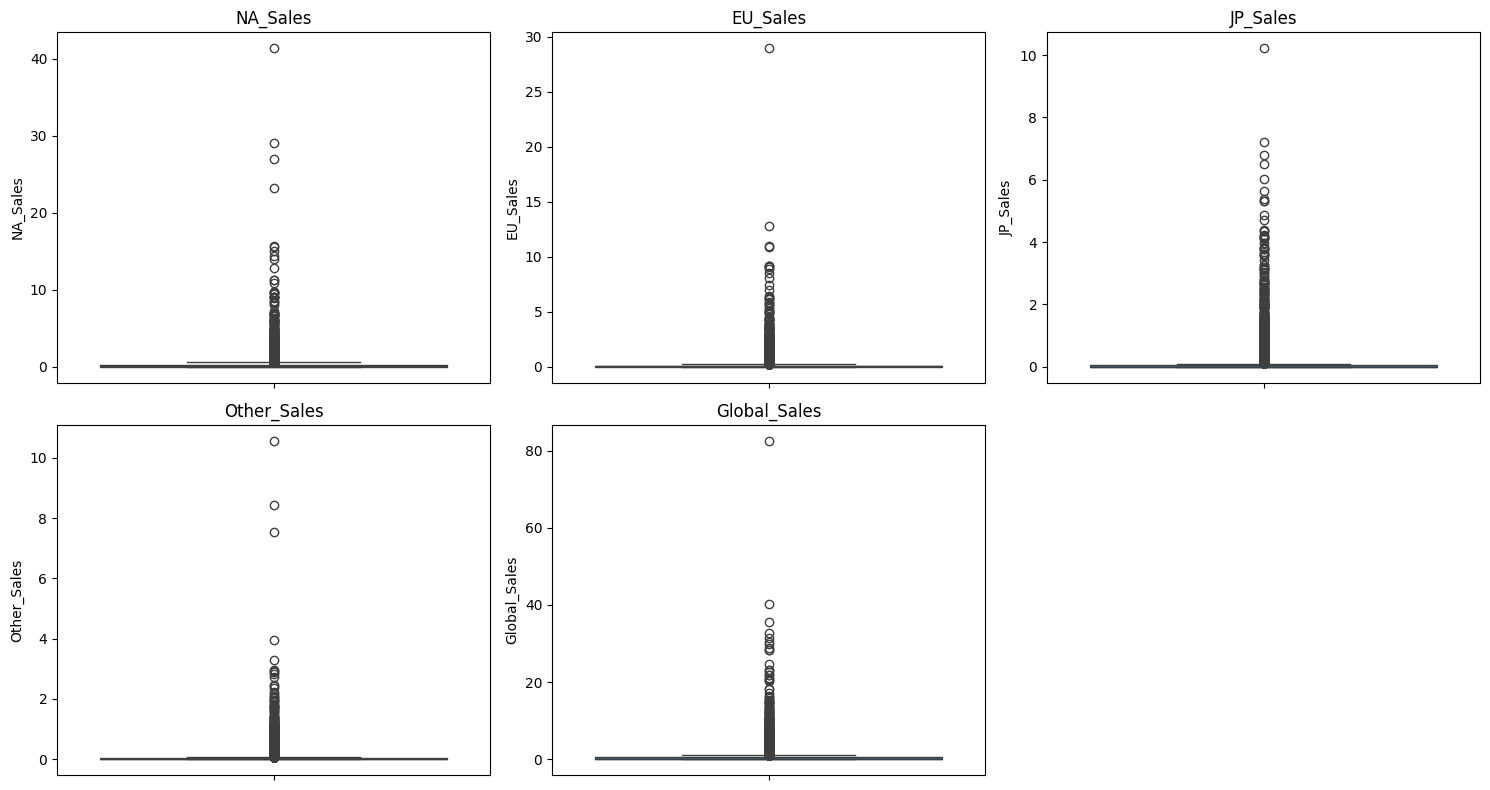

In [ ]:
# Список столбцов продаж
sales_cols = ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']

plt.figure(figsize=(15, 8))

# Проходим по каждому столбцу и строим боксплот
for i, col in enumerate(sales_cols, 1):
    plt.subplot(2, 3, i)  # создаём сетку 2x3
    sns.boxplot(y=data[col])
    plt.title(col)

plt.tight_layout()
plt.show()

Выяснили, что наши данные очень асимметричны, т е что есть и очень успешные игры, с продажами сильно выше среднего, и провальные проекты. Но в основном у нас не совсем так, поэтому на них можно смотреть как на выбросы. (Зависит от задачи.)

Прологарифмировав данные мы можем избавиться от тяжелых хвостов и сделать их более симметричными.

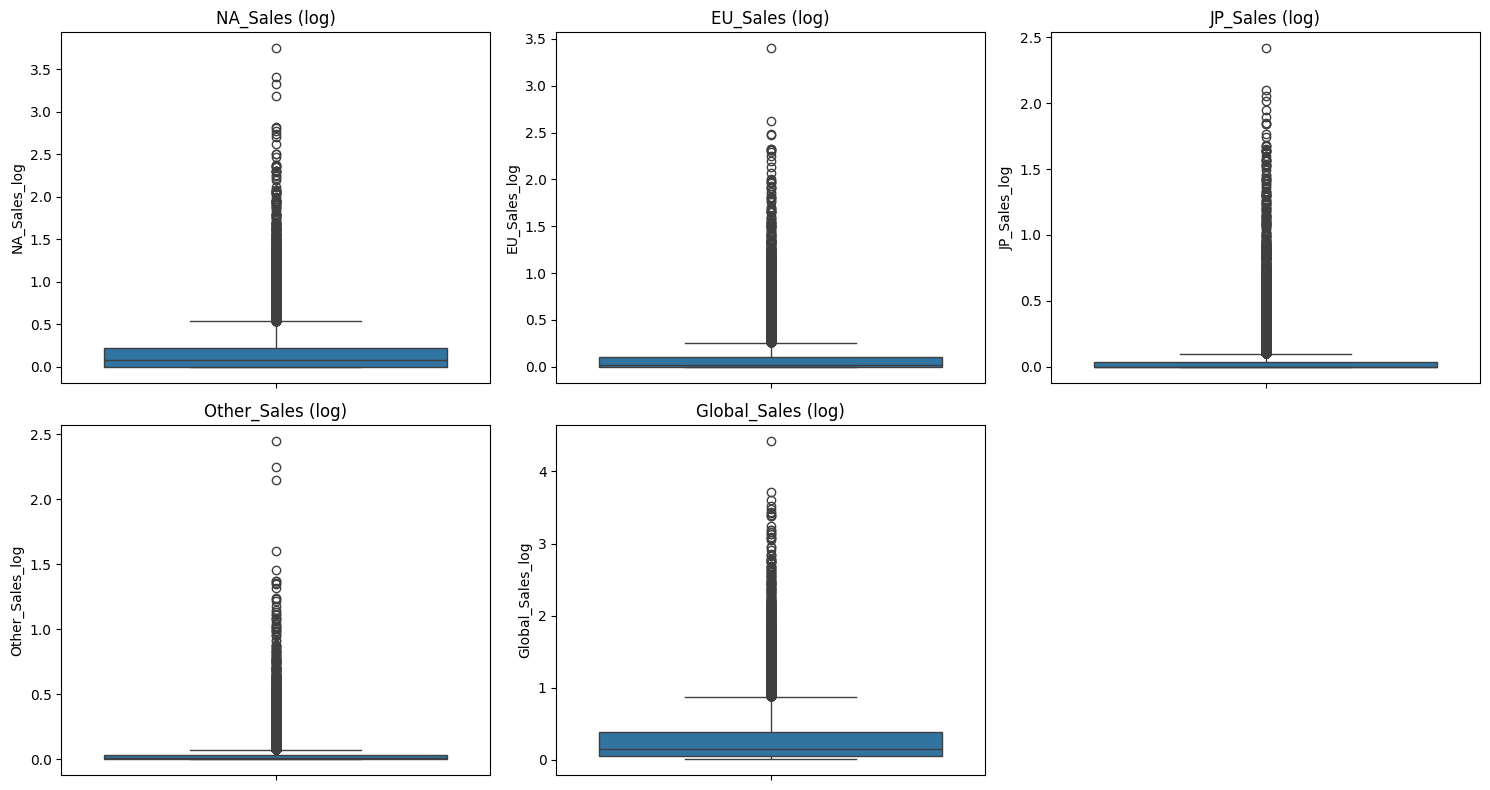

In [ ]:
# создаём логарифмированные столбцы
for col in sales_cols:
    data[col + '_log'] = np.log1p(data[col])

# визуализация
plt.figure(figsize=(15, 8))
for i, col in enumerate(sales_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=data[col + '_log'])
    plt.title(col + ' (log)')

plt.tight_layout()
plt.show()

При использовании межквартильного размаха для удаления выбросов мы потреяем большую часть данных(~6k).

In [ ]:
sales_log_cols = ['NA_Sales_log', 'EU_Sales_log', 'JP_Sales_log', 'Other_Sales_log', 'Global_Sales_log']

for col in sales_log_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    # оставляем только строки без выбросов
    data = data[(data[col] >= lower) & (data[col] <= upper)]

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10671 entries, 3882 to 16718
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Name              10671 non-null  object 
 1   Platform          10671 non-null  object 
 2   Year_of_Release   10671 non-null  float64
 3   Genre             10671 non-null  object 
 4   Publisher         10671 non-null  object 
 5   NA_Sales          10671 non-null  float64
 6   EU_Sales          10671 non-null  float64
 7   JP_Sales          10671 non-null  float64
 8   Other_Sales       10671 non-null  float64
 9   Global_Sales      10671 non-null  float64
 10  Critic_Score      10671 non-null  float64
 11  Critic_Count      10671 non-null  float64
 12  User_Score        10671 non-null  float64
 13  User_Count        10671 non-null  float64
 14  Developer         10671 non-null  object 
 15  Rating            10671 non-null  object 
 16  NA_Sales_log      10671 non-null  float64


In [ ]:
# Был другой вариант: Чтобы не удалять столько записей,
# и терять хитов индустрии, можно было их обработать - подрезать
# экстремальные значения сверху и снизу на до границ IQR. Так хиты останутся,
# но их значения будут не так разбросаны. Боксплоты будут вообще без выбросов.

# я решила так не делать, так как на мой взгляд это сильно искажает
# реальную картину, но может это не так.


# # sales_cols = ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']

# for col in sales_cols:
#     lower = data[col].quantile(0.25)
#     upper = data[col].quantile(0.75)
#     data[col] = data[col].clip(lower, upper)

# print(data[sales_cols].describe())

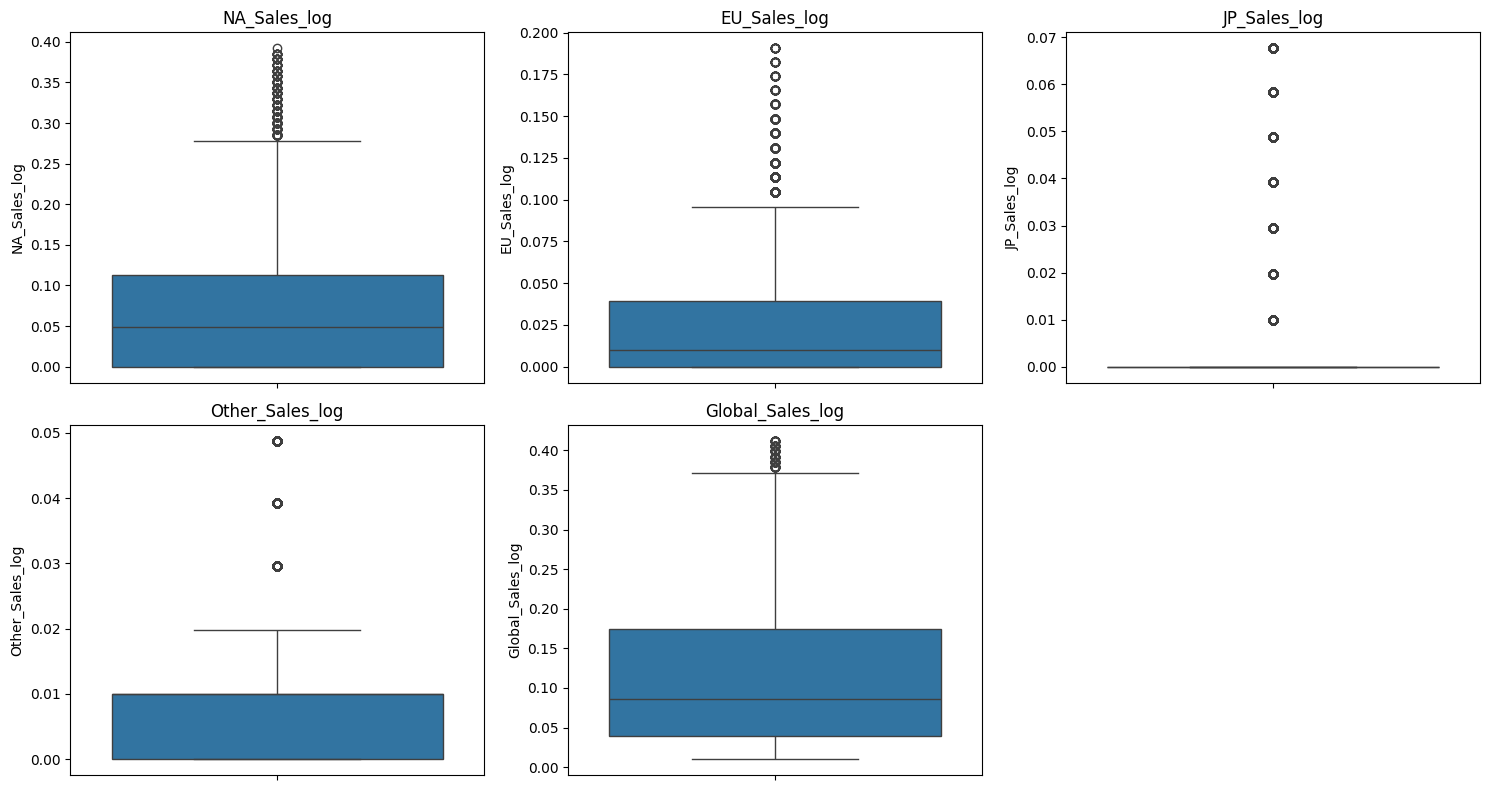

In [ ]:
plt.figure(figsize=(15, 8))

for i, col in enumerate(sales_log_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=data[col])
    plt.title(col)

plt.tight_layout()
plt.show()

Ситуация с выбросами стала лучше.
Хотя точки выше новых "усов" все еще есть, их гораздо меньше чем было изначально.

**Вывод:** с помощью ящика с усами обнаружили выбросы в продажах, удалили их с помощью межквартильного размаха.

#### 5 Обработка неправильных типов данных

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10671 entries, 3882 to 16718
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Name              10671 non-null  object 
 1   Platform          10671 non-null  object 
 2   Year_of_Release   10671 non-null  float64
 3   Genre             10671 non-null  object 
 4   Publisher         10671 non-null  object 
 5   NA_Sales          10671 non-null  float64
 6   EU_Sales          10671 non-null  float64
 7   JP_Sales          10671 non-null  float64
 8   Other_Sales       10671 non-null  float64
 9   Global_Sales      10671 non-null  float64
 10  Critic_Score      10671 non-null  float64
 11  Critic_Count      10671 non-null  float64
 12  User_Score        10671 non-null  float64
 13  User_Count        10671 non-null  float64
 14  Developer         10671 non-null  object 
 15  Rating            10671 non-null  object 
 16  NA_Sales_log      10671 non-null  float64


In [ ]:
# object -> int (можно в datetime)
data['Year_of_Release'] = data['Year_of_Release'].astype(int)

In [ ]:
# float -> int (там только целые значения)
int_cols = ['Critic_Score', 'Critic_Count', 'User_Score', 'User_Count']

for col in int_cols:
    data[col] = data[col].astype(int)

In [ ]:
# object -> категориальные
cat_cols = [ 'Platform', 'Genre', 'Rating',  'Name', 'Publisher', 'Developer']

for col in cat_cols:
    data[col] = data[col].astype('category')

In [ ]:
print(data.info())

data.head(1)

<class 'pandas.core.frame.DataFrame'>
Index: 10671 entries, 3882 to 16718
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   Name              10671 non-null  category
 1   Platform          10671 non-null  category
 2   Year_of_Release   10671 non-null  int64   
 3   Genre             10671 non-null  category
 4   Publisher         10671 non-null  category
 5   NA_Sales          10671 non-null  float64 
 6   EU_Sales          10671 non-null  float64 
 7   JP_Sales          10671 non-null  float64 
 8   Other_Sales       10671 non-null  float64 
 9   Global_Sales      10671 non-null  float64 
 10  Critic_Score      10671 non-null  int64   
 11  Critic_Count      10671 non-null  int64   
 12  User_Score        10671 non-null  int64   
 13  User_Count        10671 non-null  int64   
 14  Developer         10671 non-null  category
 15  Rating            10671 non-null  category
 16  NA_Sales_log      10671 

,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,...,Critic_Count,User_Score,User_Count,Developer,Rating,NA_Sales_log,EU_Sales_log,JP_Sales_log,Other_Sales_log,Global_Sales_log
3882,Epic Mickey 2: The Power of Two,X360,2012,Action,Disney Interactive Studios,0.32,0.15,0.0,0.04,0.51,...,35,5,22,Blitz Games Studios,E,0.277632,0.139762,0.0,0.039221,0.41211


**Вывод**: привели все признаки к корректным типам:

- Числовые признаки (`Year_of_Release`, `User_Score`, `Critic_Score`, `Critic_Count`, `User_Count`, `Sales`'ы) были приведены к `float` или `int`.

- Качественные признаки (`Platform`, `Genre`, `Publisher`, `Developer`, `Rating`, `Name`) были приведены к типу `category`.

После этой обработки все данные стали однородными, нет типа `object`.

#### 6 Преобразование качественных признаков

Этих категорий, которые представлены ниже, не так много, как в остальных качественнных признаках


In [ ]:
print(data.Platform.unique())
print(data.Genre.unique())
print(data.Rating.unique())

['X360', '2600', 'DS', 'GC', 'PS', ..., '3DO', 'GG', 'WS', 'PCFX', 'TG16']
Length: 31
Categories (31, object): ['2600', '3DO', '3DS', 'DC', ..., 'WiiU', 'X360', 'XB', 'XOne']
['Action', 'Sports', 'Role-Playing', 'Puzzle', 'Adventure', ..., 'Fighting', 'Shooter', 'Racing', 'Simulation', 'Strategy']
Length: 12
Categories (12, object): ['Action', 'Adventure', 'Fighting', 'Misc', ..., 'Shooter', 'Simulation',
                          'Sports', 'Strategy']
['E', 'Unknown', 'E10+', 'T', 'M', 'EC', 'RP', 'K-A']
Categories (8, object): ['E', 'E10+', 'EC', 'K-A', 'M', 'RP', 'T', 'Unknown']


их можно закодировать.


Если спользовать `One Hot Encoding`, то это приведет к раздуванию датасета.

Используем `LabelEncoder`, в нем каждой категории присваивается число (напр `PS3 - 1, Wii - 2, PC - …`)

In [ ]:
le = LabelEncoder()
for col in ['Platform', 'Genre', 'Rating']:
    data[col + '_code'] = le.fit_transform(data[col])
data.head(2)

,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,...,Developer,Rating,NA_Sales_log,EU_Sales_log,JP_Sales_log,Other_Sales_log,Global_Sales_log,Platform_code,Genre_code,Rating_code
3882,Epic Mickey 2: The Power of Two,X360,2012,Action,Disney Interactive Studios,0.32,0.15,0.0,0.04,0.51,...,Blitz Games Studios,E,0.277632,0.139762,0.0,0.039221,0.41211,28,0,0
3883,Fishing Derby,2600,2007,Sports,Activision,0.48,0.03,0.0,0.01,0.51,...,Unknown,Unknown,0.392042,0.029559,0.0,0.009950,0.41211,0,10,7


Однако качественные признаки `'Name'`, `'Publisher'`, `'Developer'` остались незакодированными.

(`Name` можно было бы и удалить вовсе, так как в моделях вероятнее всего этот признак не будем использовать, но пока пусть остается.)

Так как их уникальных значений очень много, можно закодировать их через `frequency encoder` (не значениями `0,...,k` а их частотой появления в дф, это дает меньше аффекта для линейных моделей, которые могуть считать новые признаки упорядоченными)



In [ ]:
for col in ['Publisher', 'Developer', 'Name']:
    freq = data[col].value_counts() / len(data)
    data[col + '_freq_code'] = data[col].map(freq)
data.head(2)

,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,...,EU_Sales_log,JP_Sales_log,Other_Sales_log,Global_Sales_log,Platform_code,Genre_code,Rating_code,Publisher_freq_code,Developer_freq_code,Name_freq_code
3882,Epic Mickey 2: The Power of Two,X360,2012,Action,Disney Interactive Studios,0.32,0.15,0.0,0.04,0.51,...,0.139762,0.0,0.039221,0.41211,28,0,0,0.011714,0.000562,0.000187
3883,Fishing Derby,2600,2007,Sports,Activision,0.48,0.03,0.0,0.01,0.51,...,0.029559,0.0,0.009950,0.41211,0,10,7,0.059882,0.375129,0.000094


**Вывод**: закодировали качественные признаки методами `Label&Frequency Encoder`

#### ❓Удалим старые признаки


Так как мы преобразовали исходные признаки (логарифмировали, закодировали категориальные), первоначальные признаки можно убрать из датасета, ибо они по сути дублируют информацию и все равно будут сильно коррелировать с новыми признаками. Однако потом их нельзя будет использовать для визуализации.

In [ ]:
data.drop(columns=['Name', 'Platform', 'Genre', 'Publisher','NA_Sales',
                   'EU_Sales','JP_Sales','Other_Sales','Global_Sales','Developer',
                   'Rating'], inplace=True)

#### 7 Разделение выборки (на тренировочную, тестовую, валидационную)

Разделим выборку в соотношении `60/20/20`




In [ ]:
# X — все признаки,
# y — целевая переменная (например, Global_Sales_log)
# При интерпертации результатов надо будет вернуться (y_pred_real = np.expm1(y_pred_log))
X = data.drop(columns=['Global_Sales_log'])
y = data['Global_Sales_log']

# сначала выделяем тренировочную 60% и временную 40% (для валидации и теста)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=42
)

# затем делим оставшиеся 40% пополам: 20% валидация, 20% тест
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

# проверим размеры выборок
print("Train:", X_train.shape, "Validation:", X_val.shape, "Test:", X_test.shape)

Train: (6402, 15) Validation: (2134, 15) Test: (2135, 15)


или в процентах:

In [ ]:
n_total = len(data)
print(f"Train: {X_train.shape[0]} ({X_train.shape[0]/n_total*100:.1f}%)")
print(f"Validation: {X_val.shape[0]} ({X_val.shape[0]/n_total*100:.1f}%)")
print(f"Test: {X_test.shape[0]} ({X_test.shape[0]/n_total*100:.1f}%)")

Train: 6402 (60.0%)
Validation: 2134 (20.0%)
Test: 2135 (20.0%)


как и ожидалось.

**Вывод**: При `random_state=42` разделили выборку на три части:

- Тренировочная выборка (`X_train, y_train`) — 60% данных (используется для обучения моделей)

- Валидационная выборка (`X_val, y_val`)— 20% данных (используется для подбора гиперпараметров и контроля переобучения)

- Тестовая выборка (`X_test, y_test`)— 20% данных (используется для финальной оценки качества модели)

#### 8 Стандартизация данных

Цель — преобразовать исходный набор в новый со средним значением равным 0 и стандартным отклонением равным 1.

Стандартизация нужна, чтобы все числовые признаки имели одинаковый масштаб. Это важно для некоторых чувствительных к нему моделей.

У нас, например, оценки критиков(0-100) и игроков(0-10) меняются в разных масштабах.

Стандартизуем числовые признаки.

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10671 entries, 3882 to 16718
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Year_of_Release      10671 non-null  int64  
 1   Critic_Score         10671 non-null  int64  
 2   Critic_Count         10671 non-null  int64  
 3   User_Score           10671 non-null  int64  
 4   User_Count           10671 non-null  int64  
 5   NA_Sales_log         10671 non-null  float64
 6   EU_Sales_log         10671 non-null  float64
 7   JP_Sales_log         10671 non-null  float64
 8   Other_Sales_log      10671 non-null  float64
 9   Global_Sales_log     10671 non-null  float64
 10  Platform_code        10671 non-null  int64  
 11  Genre_code           10671 non-null  int64  
 12  Rating_code          10671 non-null  int64  
 13  Publisher_freq_code  10671 non-null  float64
 14  Developer_freq_code  10671 non-null  float64
 15  Name_freq_code       10671 non-null  f

In [ ]:
scaler = StandardScaler()

# выбираем признаки для стандартизации
num_features = [
    'Year_of_Release',
    'Critic_Score',
    'Critic_Count',
    'User_Score',
    'User_Count',
    'NA_Sales_log',
    'EU_Sales_log',
    'Other_Sales_log'
]

# fit на train
scaler.fit(X_train[num_features])

# трансформируем train, test, val
X_train[num_features] = scaler.transform(X_train[num_features])
X_test[num_features] = scaler.transform(X_test[num_features])
X_val[num_features] = scaler.transform(X_val[num_features])

**Вывод**: стандартизировали числовые признаки (`'Year_of_Release','Critic_Score','Critic_Count',
'User_Score',
'User_Count',
'NA_Sales_log',
'EU_Sales_log',
'Other_Sales_log'`) с помощью `StandardScaler`

#### 9 Визуализация

Построим различные графики для визуализации наших данных.

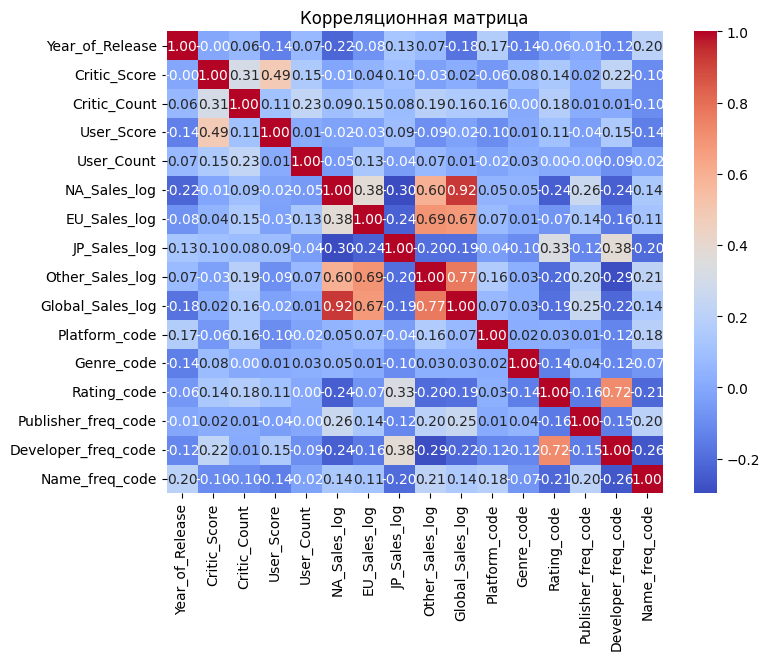

In [ ]:
# 1.Корреляционная матрица
external_corr = data.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(external_corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Корреляционная матрица')
plt.show()

In [ ]:
# 2.Диаграмма рассеяния
# sns.pairplot(data=data)

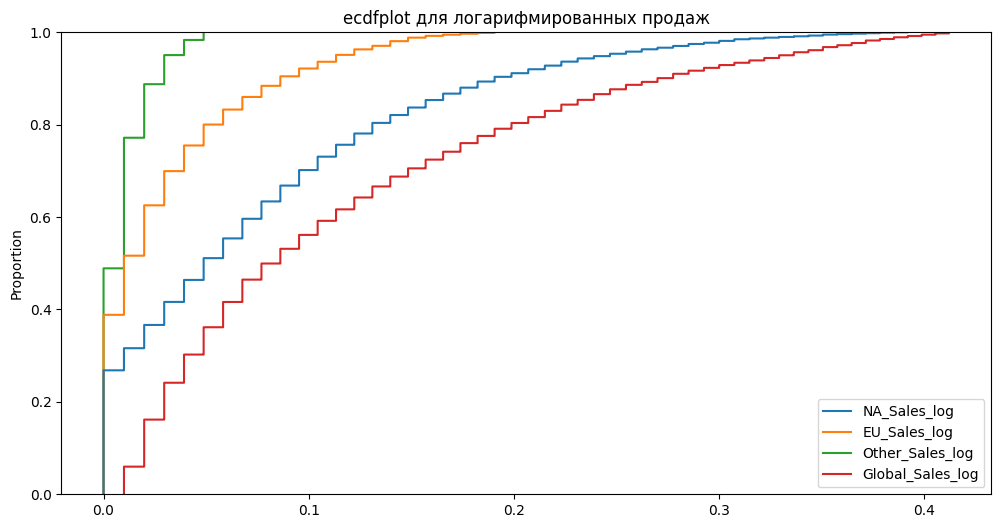

In [ ]:
# 3. ecdfplot по регионам продаж
plt.figure(figsize=(12, 6))
sns.ecdfplot(data=data[['NA_Sales_log', 'EU_Sales_log', 'Other_Sales_log', 'Global_Sales_log']])
plt.title("ecdfplot для логарифмированных продаж")
plt.show()

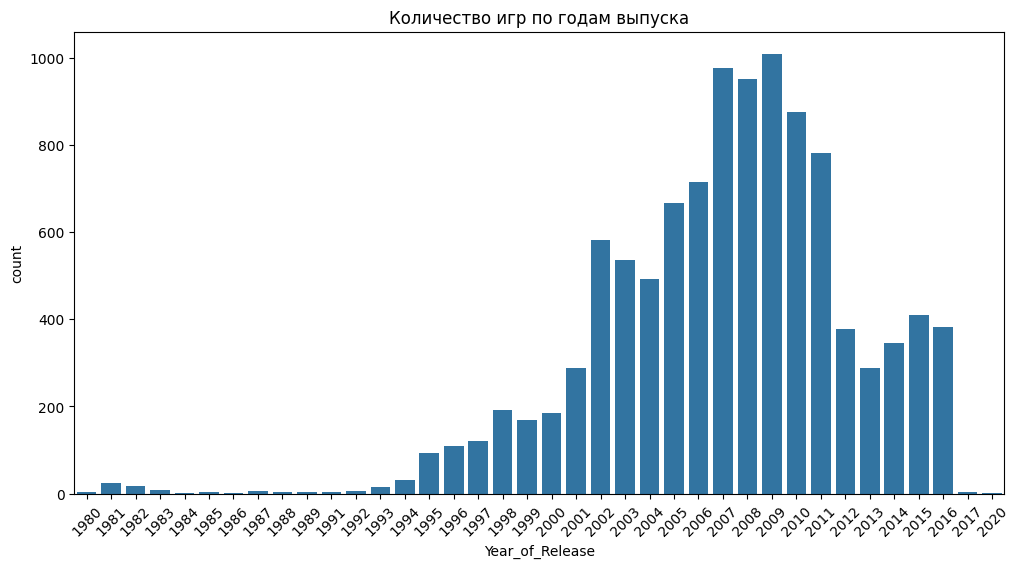

In [ ]:
# 4. Тренд по годам
plt.figure(figsize=(12, 6))
sns.countplot(x="Year_of_Release", data=data)
plt.xticks(rotation=45)
plt.title("Количество игр по годам выпуска")
plt.show()

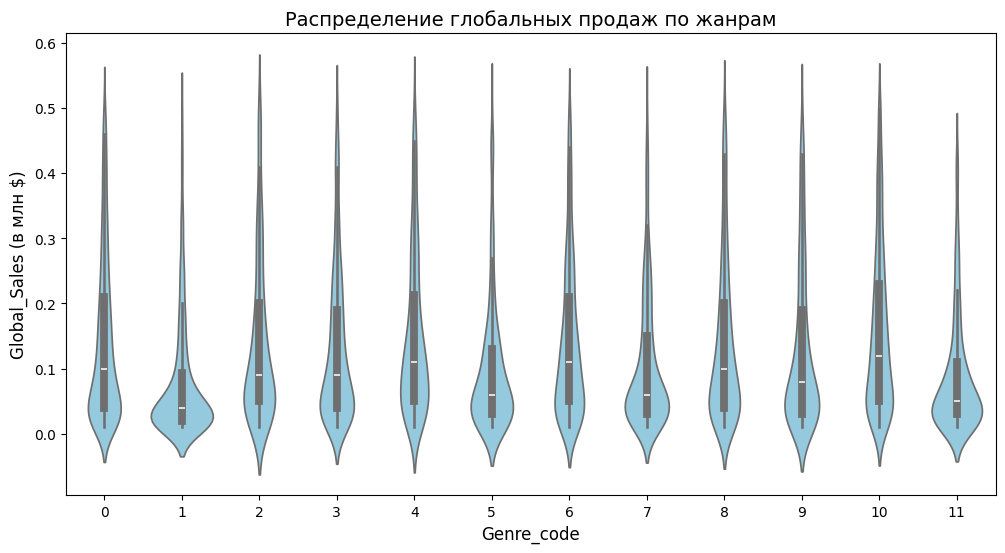

In [ ]:
# 5. Скрипичная диаграмма
plt.figure(figsize=(12, 6))
sns.violinplot(
    x="Genre_code",
    y=np.expm1(data["Global_Sales_log"]),
    data=data,
    inner="box",
    color="skyblue"
)

plt.title("Распределение глобальных продаж по жанрам", fontsize=14)
plt.xlabel("Genre_code", fontsize=12)
plt.ylabel("Global_Sales (в млн $)", fontsize=12)
plt.show()

**Вывод**: визуализация позволяет наглядно увидеть распределение признаков, выявить выбросы, зависимости

#### 10 Методы описания данных

Используем ≥ 8 разных методов описания данных

In [ ]:
print("1. Размерность датасета:", data.shape)

print("\n2.Информация о данных:")
display(data.info())

print("\n3.Первые 5 строк:")
display(data.head())

print("\n4.Последние 5 строк:")
display(data.tail())

print("\n5.Основная статистика (числовые признаки):")
display(data.describe())

print("\n6.Количество пропусков:")
display(data.isnull().sum())

print("\n7.Количество уникальных значений:")
display(data.nunique())

print("\n8.Корреляция:")
display(data.corr())

print("\n9.оценка использования памяти:")
display(data.memory_usage(deep=True))

1. Размерность датасета: (10671, 16)

2.Информация о данных:
<class 'pandas.core.frame.DataFrame'>
Index: 10671 entries, 3882 to 16718
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Year_of_Release      10671 non-null  int64  
 1   Critic_Score         10671 non-null  int64  
 2   Critic_Count         10671 non-null  int64  
 3   User_Score           10671 non-null  int64  
 4   User_Count           10671 non-null  int64  
 5   NA_Sales_log         10671 non-null  float64
 6   EU_Sales_log         10671 non-null  float64
 7   JP_Sales_log         10671 non-null  float64
 8   Other_Sales_log      10671 non-null  float64
 9   Global_Sales_log     10671 non-null  float64
 10  Platform_code        10671 non-null  int64  
 11  Genre_code           10671 non-null  int64  
 12  Rating_code          10671 non-null  int64  
 13  Publisher_freq_code  10671 non-null  float64
 14  Developer_freq_code  10671 

None


3.Первые 5 строк:


,Year_of_Release,Critic_Score,Critic_Count,User_Score,User_Count,NA_Sales_log,EU_Sales_log,JP_Sales_log,Other_Sales_log,Global_Sales_log,Platform_code,Genre_code,Rating_code,Publisher_freq_code,Developer_freq_code,Name_freq_code
3882,2012,59,35,5,22,0.277632,0.139762,0.0,0.039221,0.41211,28,0,0,0.011714,0.000562,0.000187
3883,2007,71,21,7,24,0.392042,0.029559,0.0,0.009950,0.41211,0,10,7,0.059882,0.375129,0.000094
3885,2008,70,26,7,14,0.307485,0.104360,0.0,0.039221,0.41211,4,7,1,0.011714,0.000094,0.000094
3889,2003,94,19,7,17,0.336472,0.095310,0.0,0.009950,0.41211,7,10,0,0.062974,0.003655,0.000187
3893,1997,71,21,7,24,0.246860,0.173953,0.0,0.029559,0.41211,15,10,7,0.002437,0.375129,0.000094



4.Последние 5 строк:


...

,0
Year_of_Release,38
Critic_Score,79
Critic_Count,83
User_Score,10
User_Count,444
NA_Sales_log,49
EU_Sales_log,22
JP_Sales_log,8
Other_Sales_log,6
Global_Sales_log,51



8.Корреляция:


,Year_of_Release,Critic_Score,Critic_Count,User_Score,User_Count,NA_Sales_log,EU_Sales_log,JP_Sales_log,Other_Sales_log,Global_Sales_log,Platform_code,Genre_code,Rating_code,Publisher_freq_code,Developer_freq_code,Name_freq_code
Year_of_Release,1.000000,-0.004974,0.063585,-0.135394,0.072110,-0.221161,-0.082508,0.126732,0.074327,-0.175783,0.172315,-0.140934,-0.061649,-0.005263,-0.115052,0.199811
Critic_Score,-0.004974,1.000000,0.306266,0.486239,0.149531,-0.012382,0.042722,0.101755,-0.031612,0.017338,-0.062463,0.078423,0.141035,0.018273,0.221947,-0.100208
Critic_Count,0.063585,0.306266,1.000000,0.105460,0.230355,0.093304,0.154477,0.081121,0.186785,0.155537,0.158673,0.004493,0.177142,0.012780,0.007217,-0.096815
User_Score,-0.135394,0.486239,0.105460,1.000000,0.009505,-0.022961,-0.026064,0.085784,-0.092006,-0.024118,-0.098656,0.009247,0.105482,-0.038410,0.153582,-0.141821
User_Count,0.072110,0.149531,0.230355,0.009505,1.000000,-0.050299,0.134523,-0.038972,0.069175,0.010473,-0.016537,0.025721,0.004715,-0.000324,-0.093155,-0.022207
NA_Sales_log,-0.221161,-0.012382,0.093304,-0.022961,-0.050299,1.000000,0.380489,-0.297405,0.595894,0.924402,0.046000,0.045636,-0.242382,0.260914,-0.239551,0.143025
EU_Sales_log,-0.082508,0.042722,0.154477,-0.026064,0.134523,0.380489,1.000000,-0.235728,0.691716,0.671231,0.074843,0.011314,-0.073073,0.135878,-0.156566,0.113925
JP_Sales_log,0.126732,0.101755,0.081121,0.085784,-0.038972,-0.297405,-0.235728,1.000000,-0.195593,-0.187165,-0.039114,-0.101471,0.326440,-0.119381,0.377385,-0.204852
Other_Sales_log,0.074327,-0.031612,0.186785,-0.092006,0.069175,0.595894,0.691716,-0.195593,1.000000,0.768229,0.159372,0.030792,-0.202415,0.201848,-0.288729,0.211167
Global_Sales_log,-0.175783,0.017338,0.155537,-0.024118,0.010473,0.924402,0.671231,-0.187165,0.768229,1.000000,0.070935,0.029305,-0.187093,0.254887,-0.215582,0.144024



9.оценка использования памяти:


,0
Index,85368
Year_of_Release,85368
Critic_Score,85368
Critic_Count,85368
User_Score,85368
User_Count,85368
NA_Sales_log,85368
EU_Sales_log,85368
JP_Sales_log,85368
Other_Sales_log,85368


**Вывод**: Для первичного анализа датасета использованы методы (`shape`, `info`, `head`, `tail`, `describe`, `isnull`, `nunique`, `corr`, `memory_usage`). Эти функции позволяют быстро получить ключевую информацию о структуре данных, наличии пропусков, распределении признаков, связях между переменными и размере датасета.

#### ⇒ Главный вывод по работе №1

**Главный вывод**: проведен первичный анализ, обработка пропусков и выбросов, стандартизация и кодирование признаков. подготовили датасет `Video_Games.csv` к моделированию. Данные корректны и подходят для дальнейшего построения моделей машинного обучения.

In [ ]:
data.head()

,Year_of_Release,Critic_Score,Critic_Count,User_Score,User_Count,NA_Sales_log,EU_Sales_log,JP_Sales_log,Other_Sales_log,Global_Sales_log,Platform_code,Genre_code,Rating_code,Publisher_freq_code,Developer_freq_code,Name_freq_code
3882,2012,59,35,5,22,0.277632,0.139762,0.0,0.039221,0.41211,28,0,0,0.011714,0.000562,0.000187
3883,2007,71,21,7,24,0.392042,0.029559,0.0,0.009950,0.41211,0,10,7,0.059882,0.375129,0.000094
3885,2008,70,26,7,14,0.307485,0.104360,0.0,0.039221,0.41211,4,7,1,0.011714,0.000094,0.000094
3889,2003,94,19,7,17,0.336472,0.095310,0.0,0.009950,0.41211,7,10,0,0.062974,0.003655,0.000187
3893,1997,71,21,7,24,0.246860,0.173953,0.0,0.029559,0.41211,15,10,7,0.002437,0.375129,0.000094


## 2 Обучение глубоких нейросетей

- helper functions:

In [ ]:
class TabularRegDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X.values, dtype=torch.float32)
        self.y = torch.tensor(y.values, dtype=torch.float32).view(-1, 1)
    def __len__(self):
        return len(self.y)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_ds = TabularRegDataset(X_train, y_train)
val_ds   = TabularRegDataset(X_val,   y_val)
test_ds  = TabularRegDataset(X_test,  y_test)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=64, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=64, shuffle=False)

input_dim = X_train.shape[1]

In [ ]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    for X, y in loader:
        optimizer.zero_grad()
        preds = model(X)
        loss = criterion(preds, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * X.size(0)
    return total_loss / len(loader.dataset)


def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss = 0
    preds_all, y_all = [], []
    with torch.no_grad():
        for X, y in loader:
            preds = model(X)
            loss = criterion(preds, y)
            total_loss += loss.item() * X.size(0)
            preds_all.append(preds.cpu().numpy())
            y_all.append(y.cpu().numpy())

    preds_all = np.vstack(preds_all)
    y_all = np.vstack(y_all)

    mse  = mean_squared_error(y_all, preds_all)
    rmse = mse**0.5
    mae  = mean_absolute_error(y_all, preds_all)
    r2   = r2_score(y_all, preds_all)

    return total_loss / len(loader.dataset), mse, rmse, mae, r2

In [ ]:
def fit_model(model, train_loader, val_loader, epochs=20, lr=1e-3):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    history = {"train_loss": [], "val_loss": []}
    for epoch in range(epochs):
        train_loss = train_epoch(model, train_loader, optimizer, criterion)
        val_loss, mse, rmse, mae, r2 = eval_epoch(model, val_loader, criterion)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        print(f"Epoch {epoch+1}/{epochs} | "
              f"Train: {train_loss:.4f}  Val: {val_loss:.4f}  R2: {r2:.4f}")

    return history

In [ ]:
def plot_history(history, title="Training/Validation Loss"):
    plt.figure(figsize=(7,5))
    plt.plot(history["train_loss"], label="Train Loss")
    plt.plot(history["val_loss"], label="Val Loss")
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

Baseline моделей:

Применим все 4 предложенные архитектуры, посмотрим какая будет самой удачной

-  CNN_BiLSTM

In [ ]:
class CNN_BiLSTM(nn.Module):
    def __init__(self, input_dim, hidden=64):
        super().__init__()
        self.conv = nn.Conv1d(1, 16, kernel_size=3, padding=1)
        self.lstm = nn.LSTM(16, hidden, bidirectional=True, batch_first=True)
        self.fc = nn.Linear(hidden*2, 1)

    def forward(self, x):
        x = x.unsqueeze(1)
        x = F.relu(self.conv(x))
        x = x.transpose(1,2)
        out,_ = self.lstm(x)
        out = out[:, -1, :]
        return self.fc(out)

Epoch 1/20 | Train: 0.0065  Val: 0.0026  R2: 0.7426
Epoch 2/20 | Train: 0.0018  Val: 0.0011  R2: 0.8935
Epoch 3/20 | Train: 0.0011  Val: 0.0010  R2: 0.8970
Epoch 4/20 | Train: 0.0010  Val: 0.0010  R2: 0.8981
Epoch 5/20 | Train: 0.0009  Val: 0.0007  R2: 0.9270
Epoch 6/20 | Train: 0.0007  Val: 0.0007  R2: 0.9300
Epoch 7/20 | Train: 0.0007  Val: 0.0007  R2: 0.9271
Epoch 8/20 | Train: 0.0007  Val: 0.0007  R2: 0.9339
Epoch 9/20 | Train: 0.0006  Val: 0.0007  R2: 0.9289
Epoch 10/20 | Train: 0.0006  Val: 0.0006  R2: 0.9426
Epoch 11/20 | Train: 0.0006  Val: 0.0006  R2: 0.9448
Epoch 12/20 | Train: 0.0006  Val: 0.0007  R2: 0.9328
Epoch 13/20 | Train: 0.0005  Val: 0.0005  R2: 0.9520
Epoch 14/20 | Train: 0.0005  Val: 0.0005  R2: 0.9466
Epoch 15/20 | Train: 0.0005  Val: 0.0005  R2: 0.9472
Epoch 16/20 | Train: 0.0005  Val: 0.0005  R2: 0.9540
Epoch 17/20 | Train: 0.0005  Val: 0.0004  R2: 0.9557
Epoch 18/20 | Train: 0.0005  Val: 0.0004  R2: 0.9568
Epoch 19/20 | Train: 0.0004  Val: 0.0004  R2: 0.9610
Ep

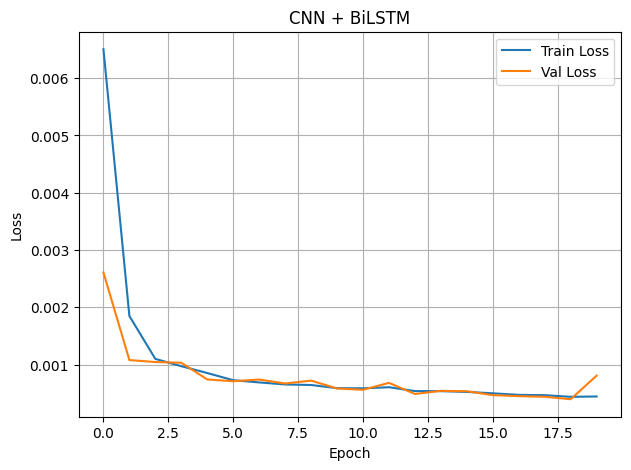

In [ ]:
model1 = CNN_BiLSTM(input_dim)
hist1 = fit_model(model1, train_loader, val_loader, epochs=20, lr=1e-3)
plot_history(hist1, "CNN + BiLSTM")

- CNN_Transformer

In [ ]:
class CNN_Transformer(nn.Module):
    def __init__(self, input_dim, embed_dim=32, nheads=4, layers=2):
        super().__init__()
        self.conv = nn.Conv1d(1, embed_dim, kernel_size=3, padding=1)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=nheads, batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=layers)

        self.fc = nn.Linear(embed_dim, 1)

    def forward(self, x):
        x = x.unsqueeze(1)
        x = self.conv(x)
        x = x.transpose(1,2)
        out = self.transformer(x)
        out = out[:, -1, :]
        return self.fc(out)

Epoch 1/20 | Train: 0.0557  Val: 0.0097  R2: 0.0386
Epoch 2/20 | Train: 0.0097  Val: 0.0083  R2: 0.1762
Epoch 3/20 | Train: 0.0069  Val: 0.0044  R2: 0.5620
Epoch 4/20 | Train: 0.0046  Val: 0.0036  R2: 0.6443
Epoch 5/20 | Train: 0.0038  Val: 0.0025  R2: 0.7560
Epoch 6/20 | Train: 0.0031  Val: 0.0020  R2: 0.8034
Epoch 7/20 | Train: 0.0028  Val: 0.0029  R2: 0.7156
Epoch 8/20 | Train: 0.0028  Val: 0.0019  R2: 0.8149
Epoch 9/20 | Train: 0.0024  Val: 0.0017  R2: 0.8295
Epoch 10/20 | Train: 0.0022  Val: 0.0034  R2: 0.6598
Epoch 11/20 | Train: 0.0024  Val: 0.0020  R2: 0.8072
Epoch 12/20 | Train: 0.0021  Val: 0.0023  R2: 0.7725
Epoch 13/20 | Train: 0.0021  Val: 0.0014  R2: 0.8578
Epoch 14/20 | Train: 0.0019  Val: 0.0014  R2: 0.8600
Epoch 15/20 | Train: 0.0018  Val: 0.0012  R2: 0.8791
Epoch 16/20 | Train: 0.0018  Val: 0.0016  R2: 0.8375
Epoch 17/20 | Train: 0.0017  Val: 0.0012  R2: 0.8854
Epoch 18/20 | Train: 0.0017  Val: 0.0012  R2: 0.8771
Epoch 19/20 | Train: 0.0016  Val: 0.0012  R2: 0.8771
Ep

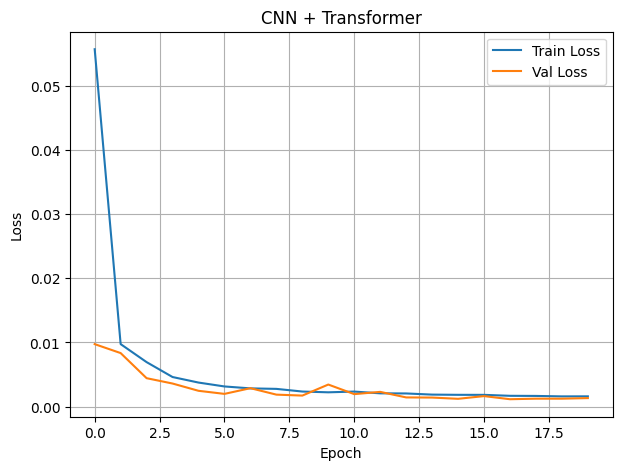

In [ ]:
model2 = CNN_Transformer(input_dim)
hist2 = fit_model(model2, train_loader, val_loader, epochs=20, lr=1e-3)
plot_history(hist2, "CNN + Transformer")

- MLP_CNN

In [ ]:
class MLP_CNN(nn.Module):
    def __init__(self, input_dim, hidden=128):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(input_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
        )

        self.conv = nn.Conv1d(1, 32, kernel_size=3, padding=1)
        self.fc = nn.Linear(32, 1)

    def forward(self, x):
        x = self.mlp(x)
        x = x.unsqueeze(1)
        x = F.relu(self.conv(x))
        x = x.mean(dim=2)
        return self.fc(x)

Epoch 1/20 | Train: 0.0490  Val: 0.0101  R2: 0.0049
Epoch 2/20 | Train: 0.0095  Val: 0.0095  R2: 0.0576
Epoch 3/20 | Train: 0.0084  Val: 0.0074  R2: 0.2718
Epoch 4/20 | Train: 0.0042  Val: 0.0012  R2: 0.8861
Epoch 5/20 | Train: 0.0006  Val: 0.0004  R2: 0.9627
Epoch 6/20 | Train: 0.0003  Val: 0.0002  R2: 0.9755
Epoch 7/20 | Train: 0.0002  Val: 0.0002  R2: 0.9812
Epoch 8/20 | Train: 0.0002  Val: 0.0002  R2: 0.9830
Epoch 9/20 | Train: 0.0002  Val: 0.0002  R2: 0.9849
Epoch 10/20 | Train: 0.0002  Val: 0.0001  R2: 0.9857
Epoch 11/20 | Train: 0.0001  Val: 0.0002  R2: 0.9842
Epoch 12/20 | Train: 0.0001  Val: 0.0001  R2: 0.9864
Epoch 13/20 | Train: 0.0001  Val: 0.0001  R2: 0.9874
Epoch 14/20 | Train: 0.0001  Val: 0.0001  R2: 0.9878
Epoch 15/20 | Train: 0.0001  Val: 0.0001  R2: 0.9869
Epoch 16/20 | Train: 0.0001  Val: 0.0001  R2: 0.9871
Epoch 17/20 | Train: 0.0001  Val: 0.0001  R2: 0.9853
Epoch 18/20 | Train: 0.0001  Val: 0.0002  R2: 0.9762
Epoch 19/20 | Train: 0.0001  Val: 0.0001  R2: 0.9886
Ep

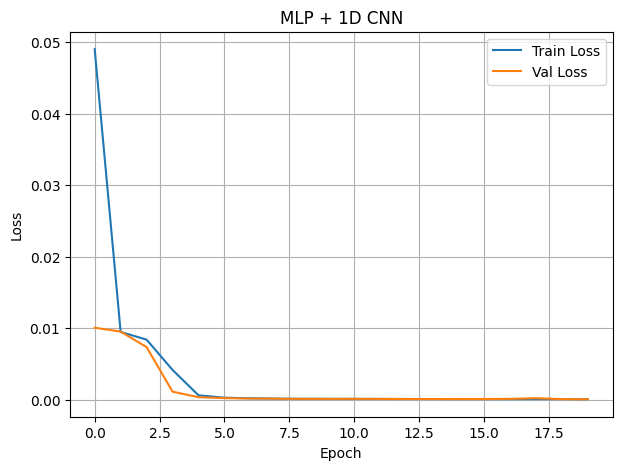

In [ ]:
model3 = MLP_CNN(input_dim)
hist3 = fit_model(model3, train_loader, val_loader, epochs=20, lr=1e-3)
plot_history(hist3, "MLP + 1D CNN")

- LSTM_GRU

In [ ]:
class LSTM_GRU(nn.Module):
    def __init__(self, input_dim, hidden=64):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden, batch_first=True)
        self.gru  = nn.GRU(hidden, hidden, batch_first=True)
        self.fc = nn.Linear(hidden, 1)

    def forward(self, x):
        x = x.unsqueeze(1)
        lstm_out,_ = self.lstm(x)
        gru_out,_  = self.gru(lstm_out)
        out = gru_out[:, -1, :]
        return self.fc(out)

Epoch 1/20 | Train: 0.0037  Val: 0.0004  R2: 0.9570
Epoch 2/20 | Train: 0.0003  Val: 0.0002  R2: 0.9812
Epoch 3/20 | Train: 0.0002  Val: 0.0002  R2: 0.9796
Epoch 4/20 | Train: 0.0001  Val: 0.0001  R2: 0.9858
Epoch 5/20 | Train: 0.0001  Val: 0.0001  R2: 0.9889
Epoch 6/20 | Train: 0.0001  Val: 0.0001  R2: 0.9897
Epoch 7/20 | Train: 0.0001  Val: 0.0001  R2: 0.9853
Epoch 8/20 | Train: 0.0001  Val: 0.0001  R2: 0.9912
Epoch 9/20 | Train: 0.0001  Val: 0.0001  R2: 0.9911
Epoch 10/20 | Train: 0.0001  Val: 0.0001  R2: 0.9923
Epoch 11/20 | Train: 0.0001  Val: 0.0001  R2: 0.9917
Epoch 12/20 | Train: 0.0000  Val: 0.0001  R2: 0.9894
Epoch 13/20 | Train: 0.0000  Val: 0.0000  R2: 0.9953
Epoch 14/20 | Train: 0.0000  Val: 0.0000  R2: 0.9967
Epoch 15/20 | Train: 0.0000  Val: 0.0000  R2: 0.9971
Epoch 16/20 | Train: 0.0000  Val: 0.0000  R2: 0.9967
Epoch 17/20 | Train: 0.0000  Val: 0.0001  R2: 0.9950
Epoch 18/20 | Train: 0.0000  Val: 0.0000  R2: 0.9972
Epoch 19/20 | Train: 0.0000  Val: 0.0000  R2: 0.9962
Ep

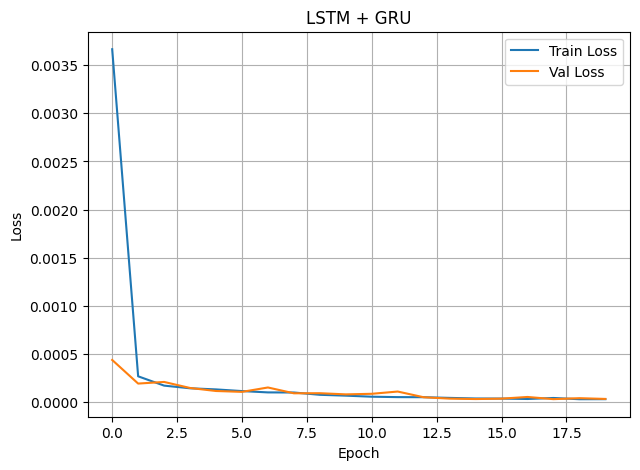

In [ ]:
model4 = LSTM_GRU(input_dim)
hist4 = fit_model(model4, train_loader, val_loader, epochs=20, lr=1e-3)
plot_history(hist4, "LSTM + GRU")

## 3 Подбор архитектуры и гиперпараметров с Optuna

- Подбор гиперпараметров

Определяем функцию (подбор только гиперпараметра lr для простоты):

In [ ]:
# Определяем устройство
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

criterion = nn.MSELoss()

def train_epoch(model, loader, optimizer):
    model.train()
    total_loss = 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device).float()
        optimizer.zero_grad()
        preds = model(xb).squeeze()
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def val_epoch(model, loader):
    model.eval()
    preds_all, y_all = [], []
    total_loss = 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device).float()
            preds = model(xb).squeeze()
            loss = criterion(preds, yb)
            total_loss += loss.item()
            preds_all.extend(preds.cpu().numpy())
            y_all.extend(yb.cpu().numpy())
    mse = mean_squared_error(y_all, preds_all)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_all, preds_all)
    r2 = r2_score(y_all, preds_all)
    return total_loss/len(loader), mse, rmse, mae, r2

def objective(trial, Model):
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    model = Model(input_dim=X_train.shape[1]).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)

    train_ds = TensorDataset(torch.tensor(X_train.values, dtype=torch.float32),
                             torch.tensor(y_train.values, dtype=torch.float32))
    val_ds = TensorDataset(torch.tensor(X_val.values, dtype=torch.float32),
                           torch.tensor(y_val.values, dtype=torch.float32))
    train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=64)

    for ep in range(5):
        train_epoch(model, train_loader, optimizer)
        val_loss, _, _, _, _ = val_epoch(model, val_loader)
        trial.report(val_loss, ep)
        if trial.should_prune():
            raise optuna.TrialPruned()
    return val_loss

def run_optuna(Model, name, n_trials=10):
    study = optuna.create_study(direction="minimize")
    study.optimize(lambda tr: objective(tr, Model), n_trials=n_trials)
    print(f"{name} best lr:", study .best_params)
    return study.best_params

Device: cpu


Запускаем подбор:

In [ ]:
best_cnn_bilstm = run_optuna(CNN_BiLSTM, "CNN+BiLSTM")

[I 2025-12-02 08:05:25,906] A new study created in memory with name: no-name-ad15d8db-8005-4fa1-ae22-c6cef465479d
[I 2025-12-02 08:05:40,175] Trial 0 finished with value: 0.0009172636885469889 and parameters: {'lr': 0.0012425206546354329}. Best is trial 0 with value: 0.0009172636885469889.
[I 2025-12-02 08:06:00,041] Trial 1 finished with value: 0.0006931410556289312 and parameters: {'lr': 0.0012593813192435944}. Best is trial 1 with value: 0.0006931410556289312.
[I 2025-12-02 08:06:16,617] Trial 2 finished with value: 0.0005027562095646691 and parameters: {'lr': 0.005367110561935207}. Best is trial 2 with value: 0.0005027562095646691.
[I 2025-12-02 08:06:31,021] Trial 3 finished with value: 0.0014151351642794907 and parameters: {'lr': 0.0003617827403785863}. Best is trial 2 with value: 0.0005027562095646691.
[I 2025-12-02 08:06:44,416] Trial 4 finished with value: 0.0006284882042296778 and parameters: {'lr': 0.007214347419122246}. Best is trial 2 with value: 0.0005027562095646691.
[I 

CNN+BiLSTM best lr: {'lr': 0.006158137257901949}


In [ ]:
best_cnn_trans = run_optuna(CNN_Transformer, "CNN+Transformer")

[I 2025-12-02 08:07:12,866] A new study created in memory with name: no-name-c2fc5f3c-d402-4f8a-a561-edf828c917ba
[I 2025-12-02 08:08:29,734] Trial 0 finished with value: 0.0029651382595629375 and parameters: {'lr': 0.001207548702045898}. Best is trial 0 with value: 0.0029651382595629375.
[I 2025-12-02 08:09:47,009] Trial 1 finished with value: 0.010307718150536804 and parameters: {'lr': 0.0075241436263539935}. Best is trial 0 with value: 0.0029651382595629375.
[I 2025-12-02 08:11:04,687] Trial 2 finished with value: 0.0036010204006315153 and parameters: {'lr': 0.005741037305420766}. Best is trial 0 with value: 0.0029651382595629375.
[I 2025-12-02 08:12:35,247] Trial 3 finished with value: 0.00758175045142279 and parameters: {'lr': 0.003593637779335533}. Best is trial 0 with value: 0.0029651382595629375.
[I 2025-12-02 08:13:52,124] Trial 4 finished with value: 0.003956317141487756 and parameters: {'lr': 0.0029696051589235017}. Best is trial 0 with value: 0.0029651382595629375.
[I 2025-

CNN+Transformer best lr: {'lr': 0.001207548702045898}


In [ ]:
best_mlp_cnn = run_optuna(MLP_CNN, "MLP+1D CNN")

[I 2025-12-02 08:15:56,223] A new study created in memory with name: no-name-d1f6ff36-583d-4116-a7bc-a68091cddd20
[I 2025-12-02 08:15:59,211] Trial 0 finished with value: 0.00013079053464667487 and parameters: {'lr': 0.005478116793702749}. Best is trial 0 with value: 0.00013079053464667487.
[I 2025-12-02 08:16:02,113] Trial 1 finished with value: 0.0002898365226642722 and parameters: {'lr': 0.007793991992786872}. Best is trial 0 with value: 0.00013079053464667487.
[I 2025-12-02 08:16:06,247] Trial 2 finished with value: 0.00013443311849294012 and parameters: {'lr': 0.004438572757662854}. Best is trial 0 with value: 0.00013079053464667487.
[I 2025-12-02 08:16:09,232] Trial 3 finished with value: 0.0009665777102140162 and parameters: {'lr': 0.0002608045680058631}. Best is trial 0 with value: 0.00013079053464667487.
[I 2025-12-02 08:16:12,241] Trial 4 finished with value: 0.00015412141660550225 and parameters: {'lr': 0.005788815847487069}. Best is trial 0 with value: 0.0001307905346466748

MLP+1D CNN best lr: {'lr': 0.005478116793702749}


In [ ]:
best_lstm_gru = run_optuna(LSTM_GRU, "LSTM+GRU")

[I 2025-12-02 08:16:18,457] A new study created in memory with name: no-name-cf7a3e1e-8cb8-4bcc-9c5b-198f0cea54eb
[I 2025-12-02 08:16:21,347] Trial 0 finished with value: 0.00020512828974888716 and parameters: {'lr': 0.0002727237535224812}. Best is trial 0 with value: 0.00020512828974888716.
[I 2025-12-02 08:16:23,804] Trial 1 finished with value: 8.169931628371534e-05 and parameters: {'lr': 0.002426777637627883}. Best is trial 1 with value: 8.169931628371534e-05.
[I 2025-12-02 08:16:26,240] Trial 2 finished with value: 0.0001686030497212949 and parameters: {'lr': 0.0003924080885845186}. Best is trial 1 with value: 8.169931628371534e-05.
[I 2025-12-02 08:16:28,601] Trial 3 finished with value: 6.209078920245006e-05 and parameters: {'lr': 0.005671423051947932}. Best is trial 3 with value: 6.209078920245006e-05.
[I 2025-12-02 08:16:31,679] Trial 4 finished with value: 0.00020851350735242972 and parameters: {'lr': 0.0003231645465197668}. Best is trial 3 with value: 6.209078920245006e-05.


LSTM+GRU best lr: {'lr': 0.0057488017834181025}


## 4 Метрики качества

Вычисляем метрики на лучших конфигурациях моделей

In [ ]:
def train_full(Model, lr, epochs=15):
    model = Model(input_dim=X_train.shape[1]).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)

    train_ds = TensorDataset(torch.tensor(X_train.values, dtype=torch.float32),
                             torch.tensor(y_train.values, dtype=torch.float32))
    val_ds = TensorDataset(torch.tensor(X_val.values, dtype=torch.float32),
                           torch.tensor(y_val.values, dtype=torch.float32))
    train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=64)

    history = {"train_loss": [], "val_loss": [], "mse": [], "rmse": [], "mae": [], "r2": []}

    for ep in range(epochs):
        tr_loss = train_epoch(model, train_loader, optimizer)
        val_loss, mse, rmse, mae, r2 = val_epoch(model, val_loader)
        history["train_loss"].append(tr_loss)
        history["val_loss"].append(val_loss)
        history["mse"].append(mse)
        history["rmse"].append(rmse)
        history["mae"].append(mae)
        history["r2"].append(r2)

    return model, history


results = {}
results["CNN+BiLSTM"] = train_full(CNN_BiLSTM, best_cnn_bilstm["lr"])
results["CNN+Transformer"] = train_full(CNN_Transformer, best_cnn_trans["lr"])
results["MLP+1D CNN"] = train_full(MLP_CNN, best_mlp_cnn["lr"])
results["LSTM+GRU"] = train_full(LSTM_GRU, best_lstm_gru["lr"])

In [ ]:
final_metrics = {}

for name, (model, hist) in results.items():
    final_metrics[name] = {
        "MSE": hist["mse"][-1],
        "RMSE": hist["rmse"][-1],
        "MAE": hist["mae"][-1],
        "R2": hist["r2"][-1]
    }

final_metrics

{'CNN+BiLSTM': {'MSE': 0.0002067379324100527,
  'RMSE': np.float64(0.014378384207206758),
  'MAE': 0.010784371748161629,
  'R2': 0.9795948791303984},
 'CNN+Transformer': {'MSE': 0.003204804794604634,
  'RMSE': np.float64(0.05661099535076763),
  'MAE': 0.040879926666086704,
  'R2': 0.6836844190369468},
 'MLP+1D CNN': {'MSE': 3.200511003418704e-05,
  'RMSE': np.float64(0.005657305898940505),
  'MAE': 0.0043328384316291555,
  'R2': 0.996841082180327},
 'LSTM+GRU': {'MSE': 4.11054504978283e-05,
  'RMSE': np.float64(0.006411353250120313),
  'MAE': 0.0051097765114531965,
  'R2': 0.9959428747495453}}

## 5 Графики обучения, валидации, переобучения и сравнение моделей.

Построим графики train/val для просмотра возможного переобучения.

Для сравнения моделей между собой построим графики с основными метриками.

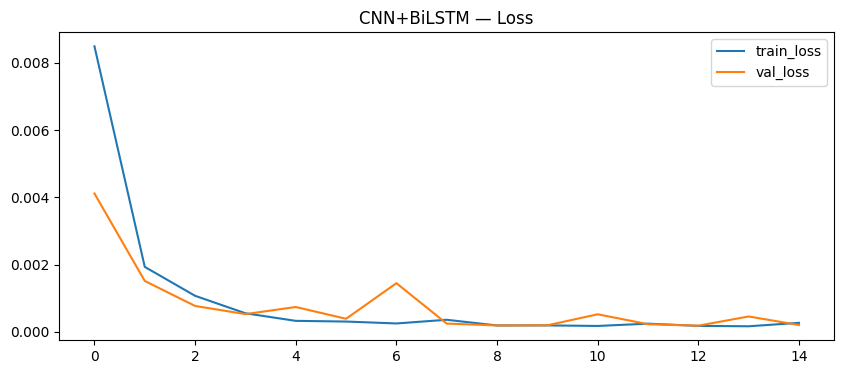

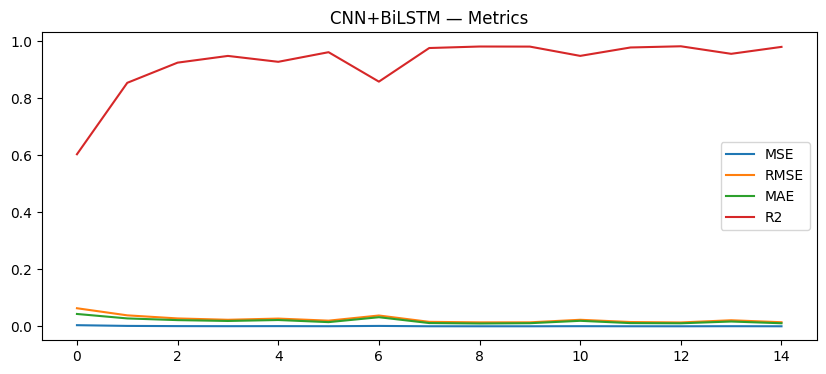

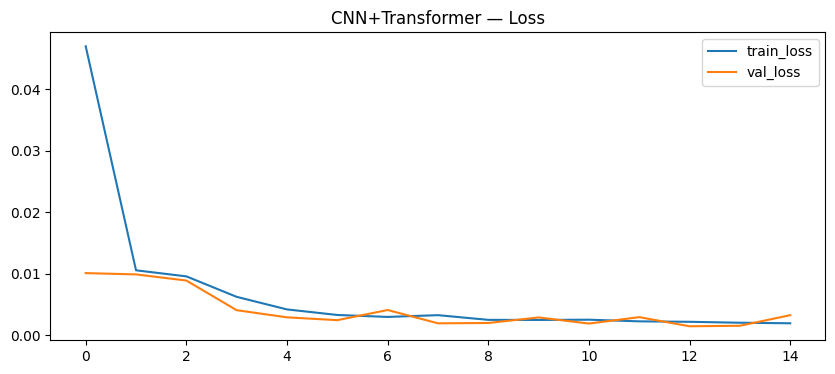

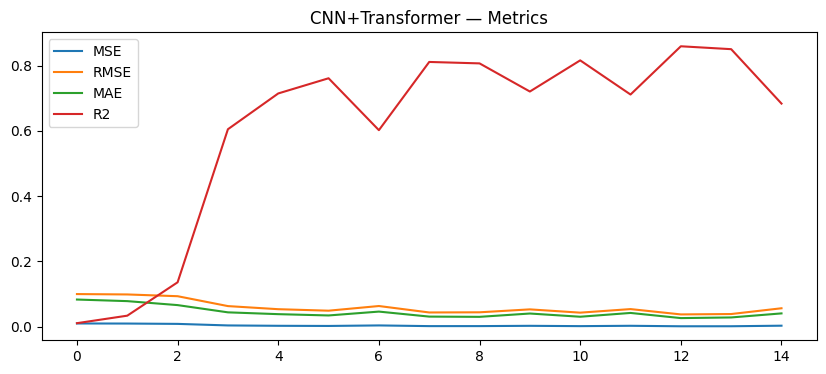

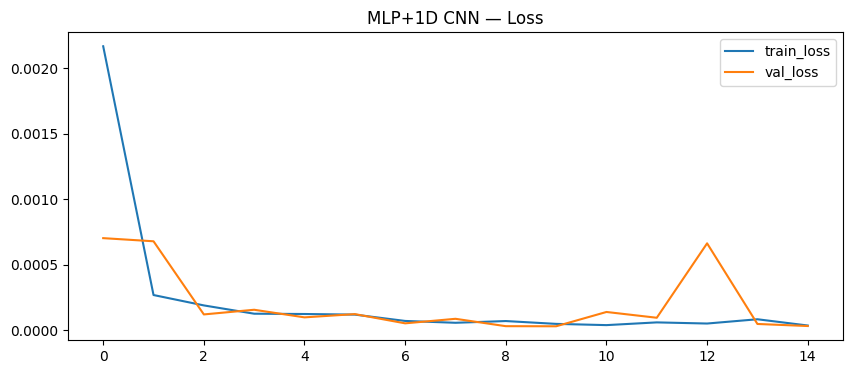

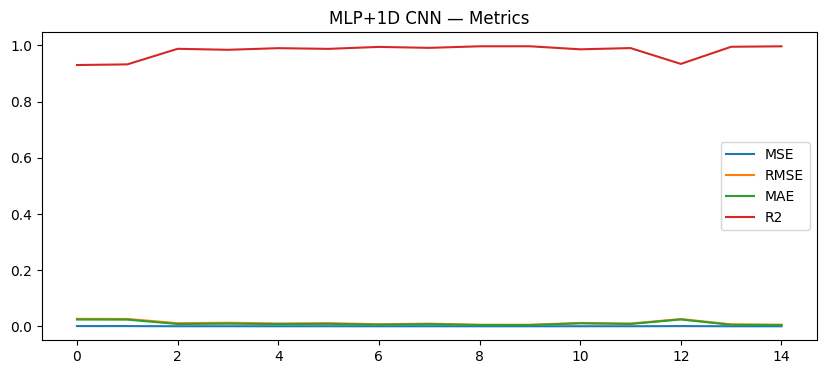

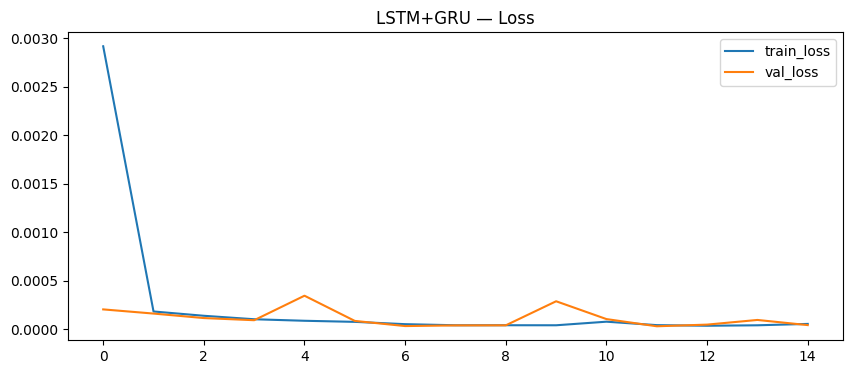

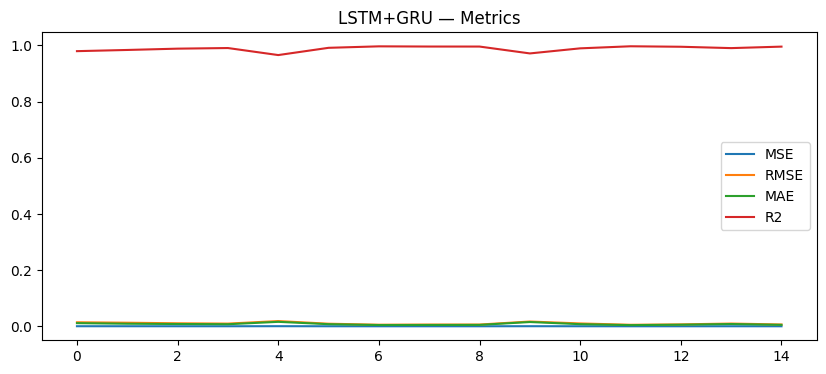

In [ ]:
def plot_history(hist, title):
    plt.figure(figsize=(10,4))
    plt.plot(hist["train_loss"], label="train_loss")
    plt.plot(hist["val_loss"], label="val_loss")
    plt.title(title + " — Loss")
    plt.legend()
    plt.show()

    plt.figure(figsize=(10,4))
    plt.plot(hist["mse"], label="MSE")
    plt.plot(hist["rmse"], label="RMSE")
    plt.plot(hist["mae"], label="MAE")
    plt.plot(hist["r2"], label="R2")
    plt.title(title + " — Metrics")
    plt.legend()
    plt.show()


for name, (_, hist) in results.items():
    plot_history(hist, name)

## 6 Анализ устойчивости моделей (например, через добавление шума или уменьшение обучающей выборки).

Сделаем и так и так.

In [ ]:
def eval_with_noise(model, noise=0.1):
    Xn = X_val.values + noise * np.random.randn(*X_val.shape)
    ds = TensorDataset(torch.tensor(Xn, dtype=torch.float32),
                       torch.tensor(y_val.values, dtype=torch.float32))
    dl = DataLoader(ds, batch_size=64)
    _, mse, rmse, mae, r2 = val_epoch(model, dl)
    return mse, rmse, mae, r2

def eval_reduced(model, frac=0.5):
    n = int(len(X_train) * frac)
    Xr, yr = X_train.values[:n], y_train.values[:n]
    ds = TensorDataset(torch.tensor(Xr, dtype=torch.float32),
                       torch.tensor(yr, dtype=torch.float32))
    dl = DataLoader(ds, batch_size=64, shuffle=True)
    _, mse, rmse, mae, r2 = val_epoch(model, dl)
    return mse, rmse, mae, r2


stability = {}
for name, (model, _) in results.items():
    stability[name] = {
        "noise": eval_with_noise(model, noise=0.2),
        "reduced": eval_reduced(model, frac=0.3)
    }

stability

{'CNN+BiLSTM': {'noise': (0.0005187871683263029,
   np.float64(0.022776899884011936),
   0.017805139920844468,
   0.9487954883175478),
  'reduced': (0.00019370880309120658,
   np.float64(0.013917930991753286),
   0.010455812883446925,
   0.9802147026850934)},
 'CNN+Transformer': {'noise': (0.003818642052790339,
   np.float64(0.06179516205003705),
   0.04468709794104434,
   0.6230984235133934),
  'reduced': (0.002797039068691142,
   np.float64(0.052887040649776784),
   0.037291565028135666,
   0.7143121598381503)},
 'MLP+1D CNN': {'noise': (0.012264681576515753,
   np.float64(0.11074602284739508),
   0.08788762815932079,
   -0.21052922934142027),
  'reduced': (3.071495603231932e-05,
   np.float64(0.005542107544275853),
   0.004183025870588608,
   0.9968627933918544)},
 'LSTM+GRU': {'noise': (0.017857024082855374,
   np.float64(0.13363017654278309),
   0.11165101551769377,
   -0.762495786498117),
  'reduced': (3.9516623289287315e-05,
   np.float64(0.006286224883766673),
   0.005060493262

К уменьшению обучающей выборки все модели устойчивы.

MLP+1D CNN LSTM+GRU менее устойчивы к шумам.

## 7 Обоснованные выводы об эффективности каждой архитектуры.

Для удобства соберем все итоги в ячейке ниже

In [ ]:
for name, (model, hist) in results.items():
    print("\n=== MODEL:", name, "===")
    print("Final MSE:", hist["mse"][-1])
    print("Final MAE:", hist["mae"][-1])
    print("Final R2:", hist["r2"][-1])
    print("Final RMSE:", hist["rmse"][-1])
    print("Noise sensitivity (RMSE):", stability[name]["noise"][1])
    print("Reduced data sensitivity (RMSE):", stability[name]["reduced"][1])


=== MODEL: CNN+BiLSTM ===
Final MSE: 0.0002067379324100527
Final MAE: 0.010784371748161629
Final R2: 0.9795948791303984
Final RMSE: 0.014378384207206758
Noise sensitivity (RMSE): 0.022776899884011936
Reduced data sensitivity (RMSE): 0.013917930991753286

=== MODEL: CNN+Transformer ===
Final MSE: 0.003204804794604634
Final MAE: 0.040879926666086704
Final R2: 0.6836844190369468
Final RMSE: 0.05661099535076763
Noise sensitivity (RMSE): 0.06179516205003705
Reduced data sensitivity (RMSE): 0.052887040649776784

=== MODEL: MLP+1D CNN ===
Final MSE: 3.200511003418704e-05
Final MAE: 0.0043328384316291555
Final R2: 0.996841082180327
Final RMSE: 0.005657305898940505
Noise sensitivity (RMSE): 0.11074602284739508
Reduced data sensitivity (RMSE): 0.005542107544275853

=== MODEL: LSTM+GRU ===
Final MSE: 4.11054504978283e-05
Final MAE: 0.0051097765114531965
Final R2: 0.9959428747495453
Final RMSE: 0.006411353250120313
Noise sensitivity (RMSE): 0.13363017654278309
Reduced data sensitivity (RMSE): 0.0

**Вывод:**
В целом видно, что трансформерность совсем не конкурирует с другими архитектурами на этих данных. Лучшие результаты у моделей рекуррентных моделей. Подробнее:

- По метрикам:

> - Сопостовимо хорошего качества моделей (R2 ≈ 0.98–0.997) достигли MLP+1D CNN; LSTM+GRU; CNN+BiLSTM.

> - Худшая модель по качеству - CNN+Transformer  (R2=0.68) - трансформер не сумел эффективно обработать эти признаки, структура данных не подходит для этой архитектуры.

- Устойчивость к шуму:

> - Лучше всего справляется CNN+BiLSTM.

> - Трансформер гдето в середине - механизмы self-attention немного помогают.

> - Хуже всего справляются LSTM+GRU и MLP+CNN.

- Уменьшенная выборка:

> - MLP+CNN и LSTM+GRU вообще почти не страдают от уменьшения данных, что говорит об их отличной обобщающей способности.

> - У CNN+BiLSTM результат немного хуже, но еще стабилен.

> - CNN+Transformer опять худший - ему критически важно большое количество данных и понятная связь между последовательностями.